# Next Word Prediction Using Recurrent Neural Networks

In [1]:
# importing the required libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import urllib.request

In [2]:
# setting seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# downloading the WikiText-2 dataset directly
url = 'https://raw.githubusercontent.com/pytorch/examples/main/word_language_model/data/wikitext-2/train.txt'
urllib.request.urlretrieve(url, 'wiki_train.txt')
print('Download complete')

Download complete


In [4]:
# loading the text file and filtering out empty lines
with open('wiki_train.txt', 'r', encoding='utf-8') as f:
    texts = [line.strip() for line in f if line.strip()]

# using only 500 lines to keep memory usage low
texts = texts[:500]
print(f'Total lines loaded: {len(texts)}')

Total lines loaded: 500


In [5]:
# tokenizing the text and building the vocabulary
VOCAB_SIZE = 10000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, lower=True, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
word_index = tokenizer.word_index
vocab_size = min(VOCAB_SIZE, len(word_index) + 1)
print(f'Vocabulary Size: {vocab_size}')

Vocabulary Size: 5380


In [6]:
# creating n-gram sequences from the tokenized text
sequences = []
max_sequence_len = 11
for text in texts:
    token_list = tokenizer.texts_to_sequences([text])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[max(0, i-10):i+1]
        sequences.append(n_gram_sequence)

In [7]:
# padding sequences so they are all the same length
sequences = pad_sequences(sequences, maxlen=max_sequence_len, padding='pre')

In [8]:
# splitting into input features and target word
X, y = sequences[:, :-1], sequences[:, -1]

In [9]:
# train-validation split
train_size = int(0.8 * len(X))
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')

X_train shape: (26972, 10), y_train shape: (26972,)


In [10]:
# data generator to feed batches during training
def data_generator(X, y, batch_size, vocab_size):
    while True:
        for start in range(0, len(X), batch_size):
            end = min(start + batch_size, len(X))
            X_batch = X[start:end]
            y_batch = y[start:end]
            yield X_batch, y_batch

batch_size = 32
train_generator = data_generator(X_train, y_train, batch_size, vocab_size)
val_generator = data_generator(X_val, y_val, batch_size, vocab_size)

In [11]:
# building the LSTM model
# embedding layer converts words to vectors, LSTM learns the sequence patterns
model = Sequential([
    Embedding(vocab_size, 50, input_length=max_sequence_len-1),
    LSTM(100),
    Dense(50, activation='relu'),
    Dense(vocab_size, activation='softmax')
])

c:\Users\varsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [12]:
# sparse categorical crossentropy is used since labels are integers not one-hot
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
# training the model for 10 epochs
history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // batch_size,
    epochs=10,
    validation_data=val_generator,
    validation_steps=len(X_val) // batch_size,
    verbose=1
)

Epoch 1/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.0734 - loss: 7.0449 - val_accuracy: 0.0768 - val_loss: 6.6681
Epoch 2/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.0767 - loss: 6.1064 - val_accuracy: 0.0771 - val_loss: 6.6588
Epoch 3/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.0758 - loss: 5.9380 - val_accuracy: 0.0775 - val_loss: 6.8609
Epoch 4/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.0766 - loss: 5.7725 - val_accuracy: 0.0805 - val_loss: 7.0915
Epoch 5/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.0837 - loss: 5.7095 - val_accuracy: 0.0866 - val_loss: 7.1799
Epoch 6/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.0865 - loss: 5.6666 - val_accuracy: 0.0898 - val_loss: 7.2680
Epoch 7/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.0908 - loss: 5.5687 - val_accuracy: 0.0901 - val_loss: 7.3075
Epoch 8/10
842/842 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.0950 - loss: 5.3980 - 

In [14]:
# evaluating on validation data
val_steps = len(X_val) // batch_size
val_loss, val_accuracy = model.evaluate(val_generator, steps=val_steps)
print(f'Validation Accuracy: {val_accuracy:.4f}')

210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0927 - loss: 8.3196
Validation Accuracy: 0.0927


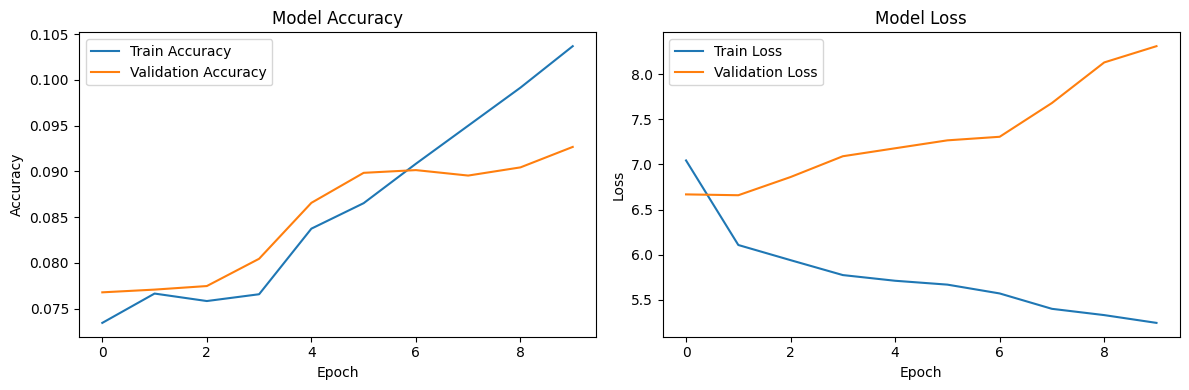

In [15]:
# plotting accuracy and loss curves to see how the model learned over time
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# function to predict the next few words given a seed text
def generate_next_word(seed_text, model, tokenizer, max_sequence_len, num_words=10):
    output_text = seed_text
    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([output_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_id = np.argmax(predicted_probs, axis=-1)[0]
        predicted_word = tokenizer.index_word.get(predicted_id, '<OOV>')
        output_text += ' ' + predicted_word
    return output_text

In [17]:
# testing the model with a sample seed text
seed_text = 'the history of'
generated_text = generate_next_word(seed_text, model, tokenizer, max_sequence_len)
print(f'Generated Text: {generated_text}')

Generated Text: the history of the gods and the gods and the gods and the


In [18]:
# saving the model
model.save('next_word_lstm_model.h5')

In [19]:
# try with different seed texts
seed_texts = [
    "the history of",
    "in the year",
    "science and technology",
    "the first world"
]

for seed in seed_texts:
    result = generate_next_word(seed, model, tokenizer, max_sequence_len)
    print(f"Input : {seed}")
    print(f"Output: {result}")
    print()

Input : the history of
Output: the history of the gods and the gods and the gods and the

Input : in the year
Output: in the year and the gods and the gods and the gods and

Input : science and technology
Output: science and technology the gods and the gods and gods and the gods

Input : the first world
Output: the first world the gods and the gods and the gods and the

